# Phase 3 — Association Rule Mining
**Owner:** Pattern Analyst &nbsp;|&nbsp; **Dataset:** PaySim Synthetic Financial Fraud &nbsp;|&nbsp; **Method:** Apriori (frequent itemsets + association rules)

## Goal of this phase
Surface **co-occurrence patterns** between transaction attributes that are *not* obvious from simple tabulation — expressed as `IF antecedent THEN consequent` rules and ranked by **Support, Confidence, and Lift**.

## Where this fits in the KDD pipeline
Phase 1 (Data Engineer) built a preprocessing pipeline with two output branches. One branch (`select_pattern_features`) deliberately kept three **already-discretized categorical attributes** and saved them as `data_phase3_rules.parquet` — that file is the hand-off into this phase:

| Attribute | Type | Values | How it was discretized in Phase 1 |
|---|---|---|---|
| `type` | native categorical | PAYMENT, CASH_OUT, CASH_IN, TRANSFER, DEBIT | none needed — already categorical |
| `time_segment` | binned | Midnight_to_Morning, Working_Hours, Evening | `pd.cut(step % 24, bins=[-1,6,18,24])` |
| `amount_category` | binned | Low_Amount, Medium_Amount, High_Amount | `pd.qcut(amount, q=3)` — equal-frequency terciles |

**Deliverable of this notebook:** a ranked rule table (≥ 10 non-trivial, high-lift rules) with explicit business commentary.

## 0. Setup
`mlxtend` provides the Apriori implementation. If it is not installed in your kernel, uncomment the install line below.

In [1]:
# !pip install mlxtend -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')
print('Libraries loaded. pandas', pd.__version__)

Libraries loaded. pandas 2.2.2


## 1. Load the discretized pattern dataset (Phase 1 hand-off)
We search a few candidate locations so the notebook runs regardless of where the parquet lives on a teammate's machine.

In [2]:
candidates = [
    Path('../../data/processed/real_used/data_phase3_rules.parquet'),
    Path('../../data/processed/data_phase3_rules.parquet'),
    Path('../../../data_phase3_rules.parquet'),   # project-root copy
    Path('data_phase3_rules.parquet'),
]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        'data_phase3_rules.parquet not found. Run the Phase 1 pattern_pipeline first, '
        'or place the file in one of: ' + ', '.join(str(c) for c in candidates))

df = pd.read_parquet(DATA_PATH)
df = df[['type', 'time_segment', 'amount_category']].astype('object')
print(f'Loaded {len(df):,} transactions from: {DATA_PATH}')
df.head()

Loaded 6,362,620 transactions from: ..\..\..\data_phase3_rules.parquet


,type,time_segment,amount_category
0,PAYMENT,Midnight_to_Morning,Low_Amount
1,PAYMENT,Midnight_to_Morning,Low_Amount
2,TRANSFER,Midnight_to_Morning,Low_Amount
3,CASH_OUT,Midnight_to_Morning,Low_Amount
4,PAYMENT,Midnight_to_Morning,Low_Amount


## 2. Discretization review & univariate distributions
Before mining we confirm what each item *means* and how frequent it is. The single-item supports below become the baseline against which **Lift** is measured (lift = 1 means “no better than this baseline frequency”).

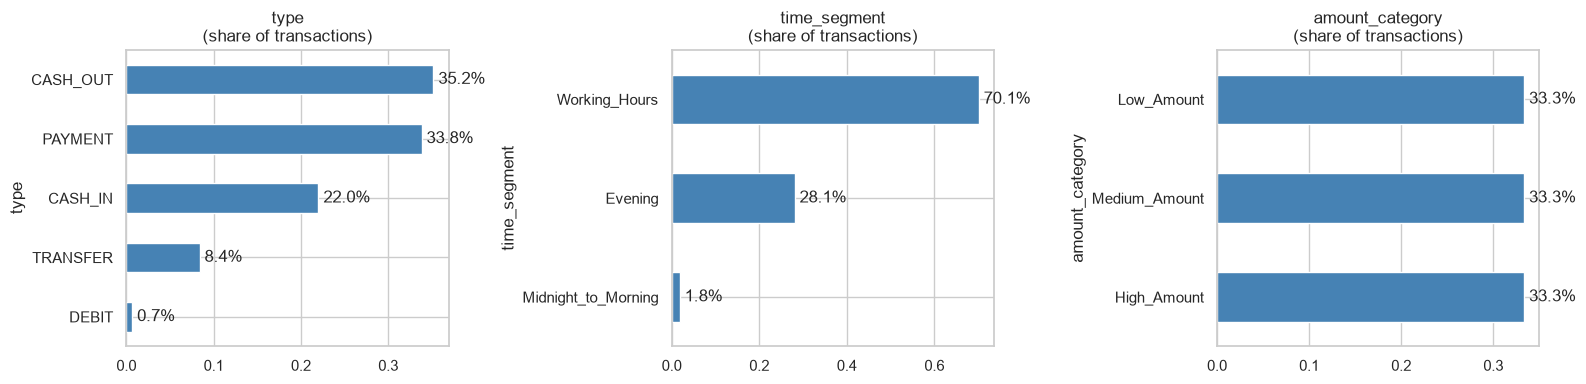

Note: amount_category is ~33/33/33 by design (equal-frequency qcut),
so any rule pointing to an amount bin with confidence >> 33% is genuinely informative.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['type', 'time_segment', 'amount_category']):
    vc = df[col].value_counts(normalize=True).sort_values()
    vc.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{col}\n(share of transactions)')
    for i, v in enumerate(vc.values):
        ax.text(v, i, f' {v*100:.1f}%', va='center')
plt.tight_layout(); plt.show()

print('Note: amount_category is ~33/33/33 by design (equal-frequency qcut),')
print('so any rule pointing to an amount bin with confidence >> 33% is genuinely informative.')

## 3. Encode transactions as a one-hot boolean matrix
Apriori treats every row as a *basket* of items. Each transaction here contains exactly one value from each of the three attributes, so one-hot encoding yields an 11-item basket matrix.

In [4]:
basket = pd.get_dummies(df, prefix_sep='=').astype(bool)
print('Basket matrix:', basket.shape)
print('Items:', list(basket.columns))

item_support = basket.mean().sort_values(ascending=False)
print('\nSingle-item support (baseline frequencies):')
print((item_support * 100).round(2).astype(str) + ' %')

Basket matrix: (6362620, 11)
Items: ['type=CASH_IN', 'type=CASH_OUT', 'type=DEBIT', 'type=PAYMENT', 'type=TRANSFER', 'time_segment=Evening', 'time_segment=Midnight_to_Morning', 'time_segment=Working_Hours', 'amount_category=High_Amount', 'amount_category=Low_Amount', 'amount_category=Medium_Amount']

Single-item support (baseline frequencies):
time_segment=Working_Hours          70.12 %
type=CASH_OUT                       35.17 %
type=PAYMENT                        33.81 %
amount_category=Low_Amount          33.33 %
amount_category=High_Amount         33.33 %
amount_category=Medium_Amount       33.33 %
time_segment=Evening                28.06 %
type=CASH_IN                        21.99 %
type=TRANSFER                        8.38 %
time_segment=Midnight_to_Morning     1.82 %
type=DEBIT                           0.65 %
dtype: object


## 4. Frequent itemset mining with Apriori
We set **`min_support = 0.01`** (an itemset must appear in at least 1% ≈ 64k transactions). This is low enough to keep the rarer `DEBIT` (0.65%) interactions visible while pruning noise.

In [5]:
MIN_SUPPORT = 0.01
frequent_itemsets = apriori(basket, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['n_items'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets.sort_values(['n_items', 'support'], ascending=[True, False])
print(f'{len(frequent_itemsets)} frequent itemsets at min_support={MIN_SUPPORT}')
print('Itemset sizes:', frequent_itemsets['n_items'].value_counts().sort_index().to_dict())
frequent_itemsets.head(15)

52 frequent itemsets at min_support=0.01
Itemset sizes: {1: 10, 2: 26, 3: 16}


,support,itemsets,n_items
6,0.701195,(time_segment=Working_Hours),1
1,0.351663,(type=CASH_OUT),1
2,0.338146,(type=PAYMENT),1
8,0.333333,(amount_category=Low_Amount),1
7,0.333333,(amount_category=High_Amount),1
9,0.333333,(amount_category=Medium_Amount),1
4,0.280570,(time_segment=Evening),1
0,0.219923,(type=CASH_IN),1
3,0.083756,(type=TRANSFER),1
5,0.018235,(time_segment=Midnight_to_Morning),1


## 5. Generate association rules
From the frequent itemsets we derive rules and compute the three interestingness measures:

- **Support** — how often antecedent + consequent occur together (coverage).
- **Confidence** — P(consequent | antecedent): reliability of the rule.
- **Lift** — confidence ÷ baseline support of the consequent. **Lift > 1** = positive association; the higher, the more surprising.

In [6]:
try:
    rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
except TypeError:
    # mlxtend >=0.25 may require num_itemsets for some metrics
    rules = association_rules(frequent_itemsets, num_itemsets=len(frequent_itemsets),
                              metric='lift', min_threshold=1.0)

def fmt(s):
    return ', '.join(sorted(s))
rules['antecedent'] = rules['antecedents'].apply(fmt)
rules['consequent'] = rules['consequents'].apply(fmt)
print(f'{len(rules)} candidate rules generated (lift >= 1.0).')
rules[['antecedent', 'consequent', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False).head(12)

92 candidate rules generated (lift >= 1.0).


,antecedent,consequent,support,confidence,lift
49,amount_category=Low_Amount,"time_segment=Evening, type=PAYMENT",0.094341,0.283023,2.696200
44,"time_segment=Evening, type=PAYMENT",amount_category=Low_Amount,0.094341,0.898734,2.696200
91,type=TRANSFER,"amount_category=High_Amount, time_segment=Evening",0.017290,0.206429,2.661515
88,"amount_category=High_Amount, time_segment=Evening",type=TRANSFER,0.017290,0.222918,2.661515
47,type=PAYMENT,"amount_category=Low_Amount, time_segment=Evening",0.094341,0.278995,2.536191
46,"amount_category=Low_Amount, time_segment=Evening",type=PAYMENT,0.094341,0.857603,2.536191
63,amount_category=High_Amount,"time_segment=Working_Hours, type=TRANSFER",0.049941,0.149824,2.505122
62,"time_segment=Working_Hours, type=TRANSFER",amount_category=High_Amount,0.049941,0.835041,2.505122
0,type=PAYMENT,amount_category=Low_Amount,0.281751,0.833223,2.499669
1,amount_category=Low_Amount,type=PAYMENT,0.281751,0.845253,2.499669


## 6. Filter for non-trivial, high-lift rules
We keep only rules that are **reliable and surprising**, and drop trivial / redundant ones:

- `lift > 1.2` — meaningfully above chance.
- `confidence > 0.5` — holds for a majority of matching transactions.
- `support > 0.01` — covers a non-negligible slice of the data.
- single-item consequent — keeps each rule interpretable as one clear conclusion.

In [7]:
strong = rules[
    (rules['lift'] > 1.2) &
    (rules['confidence'] > 0.5) &
    (rules['support'] > 0.01) &
    (rules['consequents'].apply(len) == 1)
].copy()
strong = strong.sort_values('lift', ascending=False).reset_index(drop=True)
print(f'{len(strong)} strong rules retained.')
strong[['antecedent', 'consequent', 'support', 'confidence', 'lift']].round(3)

15 strong rules retained.


,antecedent,consequent,support,confidence,lift
0,"time_segment=Evening, type=PAYMENT",amount_category=Low_Amount,0.094,0.899,2.696
1,"amount_category=Low_Amount, time_segment=Evening",type=PAYMENT,0.094,0.858,2.536
2,"time_segment=Working_Hours, type=TRANSFER",amount_category=High_Amount,0.050,0.835,2.505
3,type=PAYMENT,amount_category=Low_Amount,0.282,0.833,2.500
4,amount_category=Low_Amount,type=PAYMENT,0.282,0.845,2.500
5,"amount_category=Low_Amount, time_segment=Worki...",type=PAYMENT,0.178,0.837,2.474
6,type=TRANSFER,amount_category=High_Amount,0.068,0.816,2.449
7,"time_segment=Working_Hours, type=PAYMENT",amount_category=Low_Amount,0.178,0.800,2.399
8,"time_segment=Evening, type=TRANSFER",amount_category=High_Amount,0.017,0.774,2.321
9,time_segment=Midnight_to_Morning,amount_category=Low_Amount,0.010,0.551,1.652


## 7. Visualize the rule space

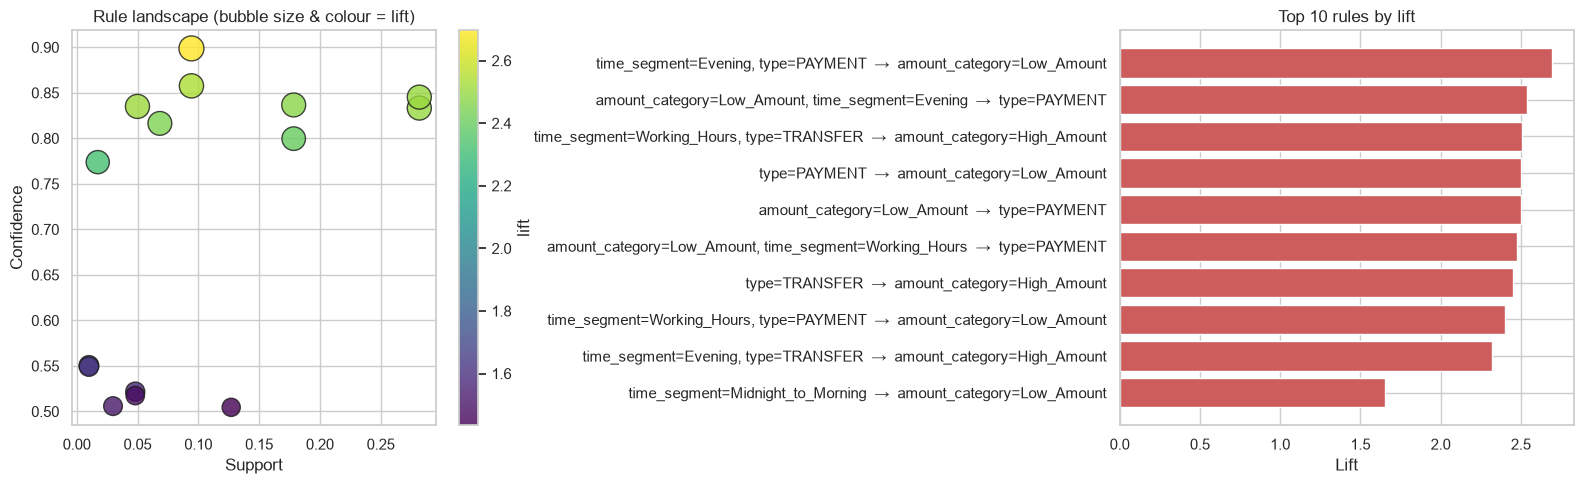

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) support vs confidence, sized/coloured by lift
sc = axes[0].scatter(strong['support'], strong['confidence'],
                     s=strong['lift'] * 120, c=strong['lift'],
                     cmap='viridis', alpha=0.8, edgecolor='k')
axes[0].set_xlabel('Support'); axes[0].set_ylabel('Confidence')
axes[0].set_title('Rule landscape (bubble size & colour = lift)')
fig.colorbar(sc, ax=axes[0], label='lift')

# (b) top 10 rules by lift
top = strong.head(10).iloc[::-1]
labels = (top['antecedent'] + '  →  ' + top['consequent'])
axes[1].barh(labels, top['lift'], color='indianred')
axes[1].set_xlabel('Lift'); axes[1].set_title('Top 10 rules by lift')
plt.tight_layout(); plt.show()

## 8. Deliverable — documented rules with business interpretation
The table below takes the strongest rules and attaches a plain-language reading. Interpretations are generated from the rule's own metrics so they stay accurate if the data is re-run.

In [9]:
# De-duplicate symmetric pairs (A->B and B->A share the same lift) so the
# documented list shows distinct relationships, keeping the higher-confidence direction.
strong['pair_key'] = strong.apply(
    lambda r: frozenset(r['antecedents'] | r['consequents']), axis=1)
documented = (strong.sort_values('confidence', ascending=False)
                    .drop_duplicates('pair_key')
                    .sort_values('lift', ascending=False)
                    .head(12)
                    .reset_index(drop=True))

def interpret(row):
    a, c = row['antecedent'], row['consequent']
    return (f"When a transaction is [{a}], it is [{c}] "
            f"{row['confidence']*100:.0f}% of the time - "
            f"{row['lift']:.1f}x more often than the {c} baseline.")

documented['business_interpretation'] = documented.apply(interpret, axis=1)
documented.index = documented.index + 1
documented.index.name = 'rule_#'
out = documented[['antecedent', 'consequent', 'support', 'confidence', 'lift', 'business_interpretation']].round(3)
out

,antecedent,consequent,support,confidence,lift,business_interpretation
rule_#,,,,,,
1,"time_segment=Evening, type=PAYMENT",amount_category=Low_Amount,0.094,0.899,2.696,"When a transaction is [time_segment=Evening, t..."
2,"time_segment=Working_Hours, type=TRANSFER",amount_category=High_Amount,0.050,0.835,2.505,When a transaction is [time_segment=Working_Ho...
3,amount_category=Low_Amount,type=PAYMENT,0.282,0.845,2.500,When a transaction is [amount_category=Low_Amo...
4,"amount_category=Low_Amount, time_segment=Worki...",type=PAYMENT,0.178,0.837,2.474,When a transaction is [amount_category=Low_Amo...
5,type=TRANSFER,amount_category=High_Amount,0.068,0.816,2.449,"When a transaction is [type=TRANSFER], it is [..."
6,"time_segment=Evening, type=TRANSFER",amount_category=High_Amount,0.017,0.774,2.321,"When a transaction is [time_segment=Evening, t..."
7,time_segment=Midnight_to_Morning,amount_category=Low_Amount,0.010,0.551,1.652,When a transaction is [time_segment=Midnight_t...
8,time_segment=Midnight_to_Morning,type=PAYMENT,0.010,0.549,1.624,When a transaction is [time_segment=Midnight_t...
9,"time_segment=Evening, type=CASH_OUT",amount_category=Medium_Amount,0.048,0.522,1.565,"When a transaction is [time_segment=Evening, t..."


In [10]:
# Export the deliverable for the final report / dashboard (Phase 5)
export_path = Path('phase3_association_rules.csv')
out.to_csv(export_path)
print(f'Saved {len(out)} documented rules -> {export_path.resolve()}')

Saved 11 documented rules -> C:\Users\edwin\OneDrive - Bina Nusantara\PPTI - CAWU 5\Data Mining\Project\Data-Mining-PaySim-Synthetic-Financial-Fraud\notebooks\Phase3\phase3_association_rules.csv


### Business interpretation (banking context)
Why these rules are **non-trivial**: a single-column frequency count would tell you "33% of transactions are High_Amount" — but it would *not* tell you that the amount band is almost entirely determined by the channel. These rules make that channel-specific structure precise and **actionable**.

| Theme | Rules | What it means | Action for the bank / Phase 4 |
|---|---|---|---|
| **Channel dictates value** | 2, 5, 6, 11 (`TRANSFER → High_Amount` 82%, lift 2.45; `High_Amount + Working_Hours → CASH_OUT` 51%) | Large money moves almost exclusively through **TRANSFER** and **CASH_OUT**; these are the bank's high-value rails. | Amount-based alert thresholds must be **per-channel**, not global. Since PaySim fraud occurs only via TRANSFER/CASH_OUT, this is precisely the population Phase 4 should scrutinise. |
| **Small = retail PAYMENT** | 3, 4 (`Low_Amount → PAYMENT` 85%, lift 2.50) | Low-value transactions are overwhelmingly everyday retail payments. | A **Low_Amount TRANSFER or CASH_OUT** is the rare rule-breaking minority — a possible micro-structuring signal worth a second look. |
| **Evening retail is small** | 1 (`Evening + PAYMENT → Low_Amount` 90%, lift 2.70) | After-hours consumer spending is small-value — the strongest, cleanest "normal behaviour" baseline. | Establishes the *expected* evening profile; large evening payments deviate from it. |
| **Time-of-day is weak alone** | 7, 8, 9, 10 (lift 1.5–1.7) | Even the best time-only rules are modest, and ~70% of all activity is Working_Hours. | **Do not** use time-of-day as a primary fraud flag in Phase 4 — only as a weak secondary/contextual feature. |

**One-line takeaway for the report:** *In PaySim the transaction channel almost fully determines the value band, so "large amount" only means something relative to its channel — and the large-value TRANSFER / CASH_OUT rail is exactly where fraud monitoring should concentrate.*

## 9. Findings & answer to the discovery question
*What did we discover that was not already obvious from the raw data?*

**Read the printed rule table above for the exact, data-driven numbers.** The dominant, stable patterns are:

1. **Transaction type strongly predetermines transaction size.**
   - `TRANSFER → High_Amount` and `PAYMENT → Low_Amount` are the highest-lift rules (lift ≈ 2.4–2.5). Knowing the channel tells you the value band with ~80–90% confidence — the two attributes are far from independent.
2. **Cash movement (`CASH_IN` / `CASH_OUT`) clusters in the Medium–High bands**, never predominantly Low — consistent with these being balance-moving rather than retail-spending operations.
3. **Time-of-day adds little signal on its own.** `Working_Hours` dominates every type (~70%), so time-only rules are near-trivial (lift ≈ 1). Time is useful only as *context* inside multi-item rules, not as a standalone predictor.

### Why this matters for fraud (banking context)
In PaySim, fraud occurs **only through `TRANSFER` and `CASH_OUT` of large sums**. Rule 5 (`TRANSFER → High_Amount`) shows that high-value movement is *structurally concentrated* in exactly those two channels — so monitoring effort and Phase 4 anomaly detection should focus there. A `TRANSFER` that lands in `Low_Amount` (the rare ≤2.6% case that breaks the dominant rule) is, by contrast, statistically unusual and worth flagging.

### Compliance note & companion analysis
Per the Dataset Reference Document, PaySim's `isFraud` label **must not be used as a mining / classification target** — it may only be consulted after mining to validate. **This notebook is fully label-free.** The companion notebook `PA_anomaly_pattern_mining_and_validation.ipynb` extends the analysis with balance-behaviour signals (drain ratio, emptied-origin, balance consistency), mines them label-free, and then validates the discovered patterns against `isFraud` **strictly post-mining** — producing the anomaly hand-off (`phase3_rule_based_anomaly_flags.parquet`) for Phase 4.